In [1]:
!pip install fastf1 matplotlib pandas 


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 531.8 kB/s eta 0:00:02
   ------------- -------------------------- 0.5/1.5 MB 531.8 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/1.5 MB 584.6 kB/s eta 0:00:02
   -------------------- ------------------- 0.8/1.5 MB 584.6 kB/s eta 0:00:02
   --------------------------- ------------ 1.0/1.5 MB 616.9 kB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 662.9 kB/s eta 0:00:01
   ---------------------------------------- 1.5/1

  You can safely remove it manually.


req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) C:\Users\User\AppData\Local\Temp\fastf1
core           INFO 	Loading data for British Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           

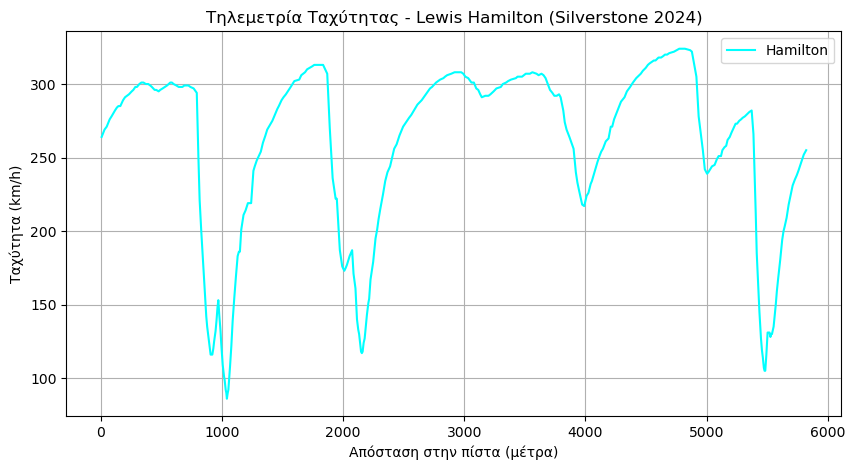

In [4]:
import fastf1
from fastf1 import plotting
import matplotlib.pyplot as plt

# Προετοιμασία της βιβλιοθήκης για όμορφα γραφήματα F1
plotting.setup_mpl()

# 1. Φορτώνουμε το Grand Prix της Μεγάλης Βρετανίας 2024 (Qualifying)
# Σημείωση: Την πρώτη φορά θα πάρει λίγη ώρα γιατί κατεβάζει τα δεδομένα
session = fastf1.get_session(2024, 'Silverstone', 'Q')
session.load()

# 2. Παίρνουμε τον ταχύτερο γύρο του Hamilton (HAM)
ham_lap = session.laps.pick_driver('HAM').pick_fastest()

# 3. Παίρνουμε τα δεδομένα τηλεμετρίας για αυτόν τον γύρο
ham_telemetry = ham_lap.get_car_data().add_distance()

# 4. Σχεδιάζουμε το γράφημα: Απόσταση (X) και Ταχύτητα (Y)
plt.figure(figsize=(10, 5))
plt.plot(ham_telemetry['Distance'], ham_telemetry['Speed'], label='Hamilton', color='cyan')

# Ονομασίες στους άξονες
plt.xlabel('Απόσταση στην πίστα (μέτρα)')
plt.ylabel('Ταχύτητα (km/h)')
plt.title('Τηλεμετρία Ταχύτητας - Lewis Hamilton (Silverstone 2024)')
plt.legend()
plt.grid(True)

# Εμφάνιση του γραφήματος
plt.show()

In [2]:
import fastf1
from fastf1 import plotting
import matplotlib.pyplot as plt

# Προετοιμασία της βιβλιοθήκης για όμορφα γραφήματα F1
plotting.setup_mpl()

# Ενεργοποίηση της προσωρινής μνήμης (cache) για να κατεβαίνουν τα δεδομένα γρήγορα
fastf1.Cache.enable_cache('cache_dir') 

# 1. Φορτώνουμε το Grand Prix της Μεγάλης Βρετανίας 2024 (Qualifying)
session = fastf1.get_session(2024, 'Silverstone', 'Q')
session.load()

# 2. Παίρνουμε τον ταχύτερο γύρο του Hamilton (HAM)
ham_lap = session.laps.pick_driver('HAM').pick_fastest()

# 3. Παίρνουμε τα δεδομένα τηλεμετρίας για αυτόν τον γύρο
ham_telemetry = ham_lap.get_car_data().add_distance()

# 4. Σχεδιάζουμε το γράφημα: Απόσταση (X) και Ταχύτητα (Y)
plt.figure(figsize=(10, 5))
plt.plot(ham_telemetry['Distance'], ham_telemetry['Speed'], label='Hamilton', color='cyan')

# Ονομασίες στους άξονες
plt.xlabel('Απόσταση στην πίστα (μέτρα)')
plt.ylabel('Ταχύτητα (km/h)')
plt.title('Τηλεμετρία Ταχύτητας - Lewis Hamilton (Silverstone 2024)')
plt.legend()
plt.grid(True)

# Εμφάνιση του γραφήματος
plt.show()

NotADirectoryError: Cache directory does not exist! Please check for typos or create it first.

C:\Users\User\anaconda3\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


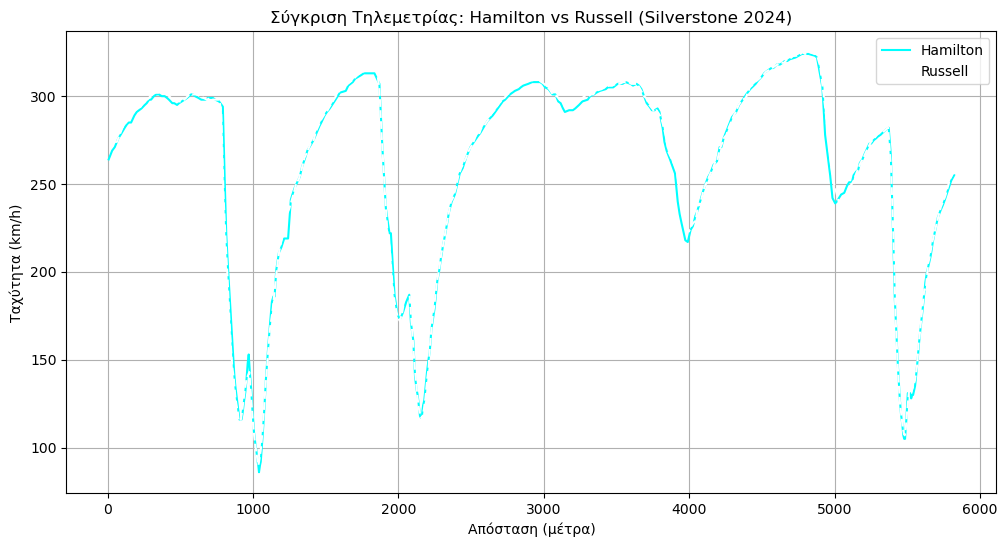

In [5]:
# 1. Παίρνουμε τον ταχύτερο γύρο του Russell (RUS)
rus_lap = session.laps.pick_driver('RUS').pick_fastest()

# 2. Παίρνουμε τηλεμετρία για τον Russell
rus_telemetry = rus_lap.get_car_data().add_distance()

# 3. Φτιάχνουμε το κοινό γράφημα
plt.figure(figsize=(12, 6))

# Γραμμή για Hamilton (Cyan)
plt.plot(ham_telemetry['Distance'], ham_telemetry['Speed'], label='Hamilton', color='cyan')
# Γραμμή για Russell (Silver/White)
plt.plot(rus_telemetry['Distance'], rus_telemetry['Speed'], label='Russell', color='white', linestyle='--')

plt.xlabel('Απόσταση (μέτρα)')
plt.ylabel('Ταχύτητα (km/h)')
plt.title('Σύγκριση Τηλεμετρίας: Hamilton vs Russell (Silverstone 2024)')
plt.legend()
plt.grid(True)
plt.show()

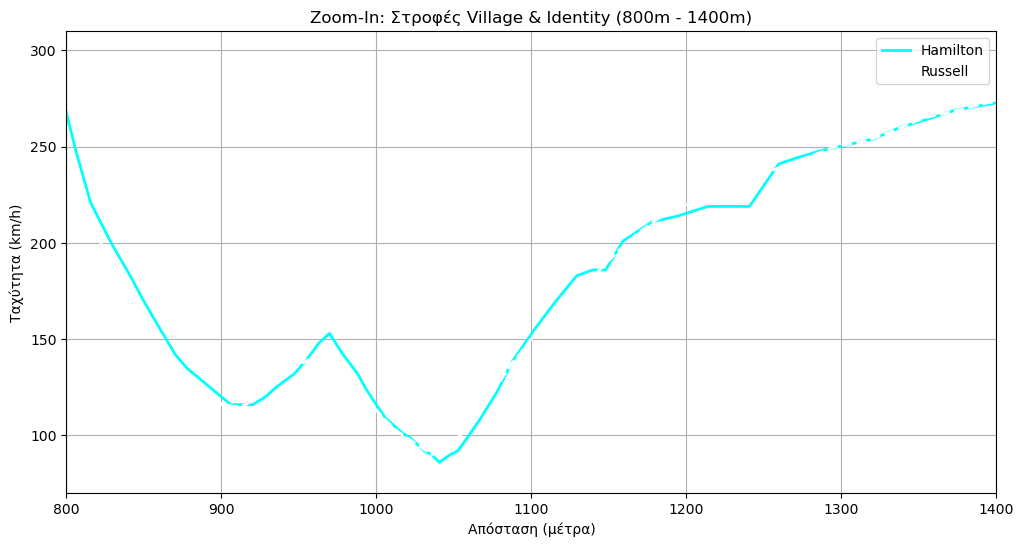

In [6]:
plt.figure(figsize=(12, 6))

# Σχεδιάζουμε πάλι τις γραμμές
plt.plot(ham_telemetry['Distance'], ham_telemetry['Speed'], label='Hamilton', color='cyan', linewidth=2)
plt.plot(rus_telemetry['Distance'], rus_telemetry['Speed'], label='Russell', color='white', linestyle='--', linewidth=2)

# ΕΔΩ ΕΙΝΑΙ ΤΟ ΚΟΛΠΟ: Ορίζουμε τα όρια του άξονα Χ για να κάνουμε Zoom στην πρώτη φουρκέτα
plt.xlim(800, 1400) 
plt.ylim(70, 310) # Zoom και στον άξονα Υ για να φαίνονται οι καθαρές ταχύτητες στροφής

plt.xlabel('Απόσταση (μέτρα)')
plt.ylabel('Ταχύτητα (km/h)')
plt.title('Zoom-In: Στροφές Village & Identity (800m - 1400m)')
plt.legend()
plt.grid(True)
plt.show()

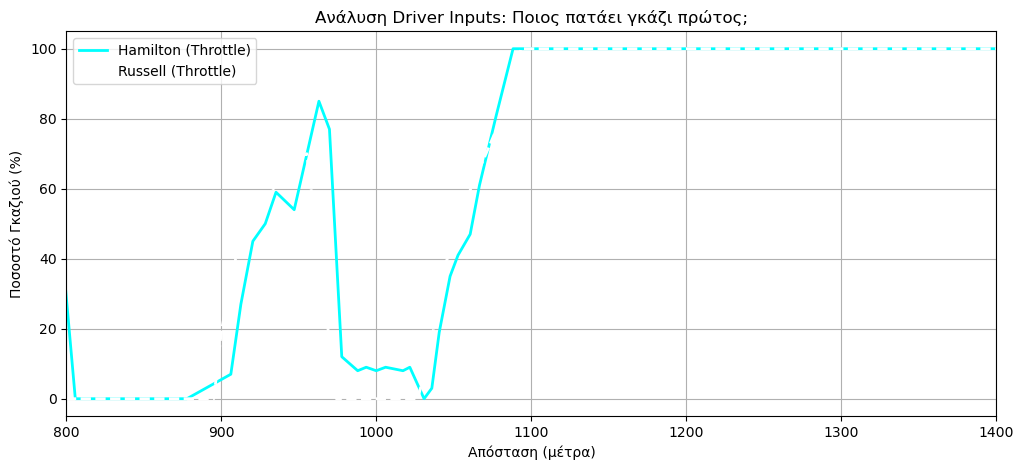

In [7]:
plt.figure(figsize=(12, 5))

# Σχεδιάζουμε το γκάζι (Throttle) για τους δύο οδηγούς
plt.plot(ham_telemetry['Distance'], ham_telemetry['Throttle'], label='Hamilton (Throttle)', color='cyan', linewidth=2)
plt.plot(rus_telemetry['Distance'], rus_telemetry['Throttle'], label='Russell (Throttle)', color='white', linestyle='--', linewidth=2)

# Κάνουμε Zoom ακριβώς στο ίδιο σημείο
plt.xlim(800, 1400) 

plt.xlabel('Απόσταση (μέτρα)')
plt.ylabel('Ποσοστό Γκαζιού (%)')
plt.title('Ανάλυση Driver Inputs: Ποιος πατάει γκάζι πρώτος;')
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'Gear'

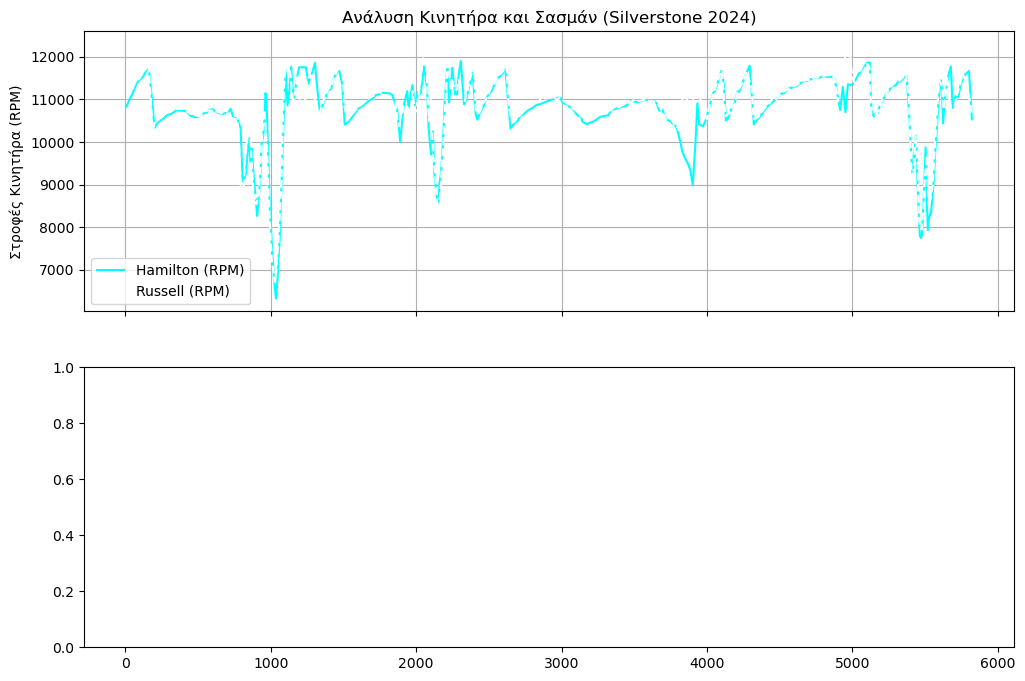

In [8]:
# Φτιάχνουμε ένα γράφημα με δύο υπο-γραφήματα (ένα για RPM και ένα για Gears)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 1. Πάνω γράφημα: Στροφές Κινητήρα (RPM)
ax[0].plot(ham_telemetry['Distance'], ham_telemetry['RPM'], label='Hamilton (RPM)', color='cyan')
ax[0].plot(rus_telemetry['Distance'], rus_telemetry['RPM'], label='Russell (RPM)', color='white', linestyle='--')
ax[0].set_ylabel('Στροφές Κινητήρα (RPM)')
ax[0].title.set_text('Ανάλυση Κινητήρα και Σασμάν (Silverstone 2024)')
ax[0].legend()
ax[0].grid(True)

# 2. Κάτω γράφημα: Σχέση στο Κιβώτιο (Gear)
ax[1].plot(ham_telemetry['Distance'], ham_telemetry['Gear'], label='Hamilton (Gear)', color='cyan')
ax[1].plot(rus_telemetry['Distance'], rus_telemetry['Gear'], label='Russell (Gear)', color='white', linestyle='--')
ax[1].set_ylabel('Σχέση Κιβωτίου (1-8)')
ax[1].set_xlabel('Απόσταση (μέτρα)')
ax[1].legend()
ax[1].grid(True)

# Κάνουμε Zoom στο ίδιο ακριβώς σημείο (800m - 1400m)
plt.xlim(800, 1400)

plt.show()

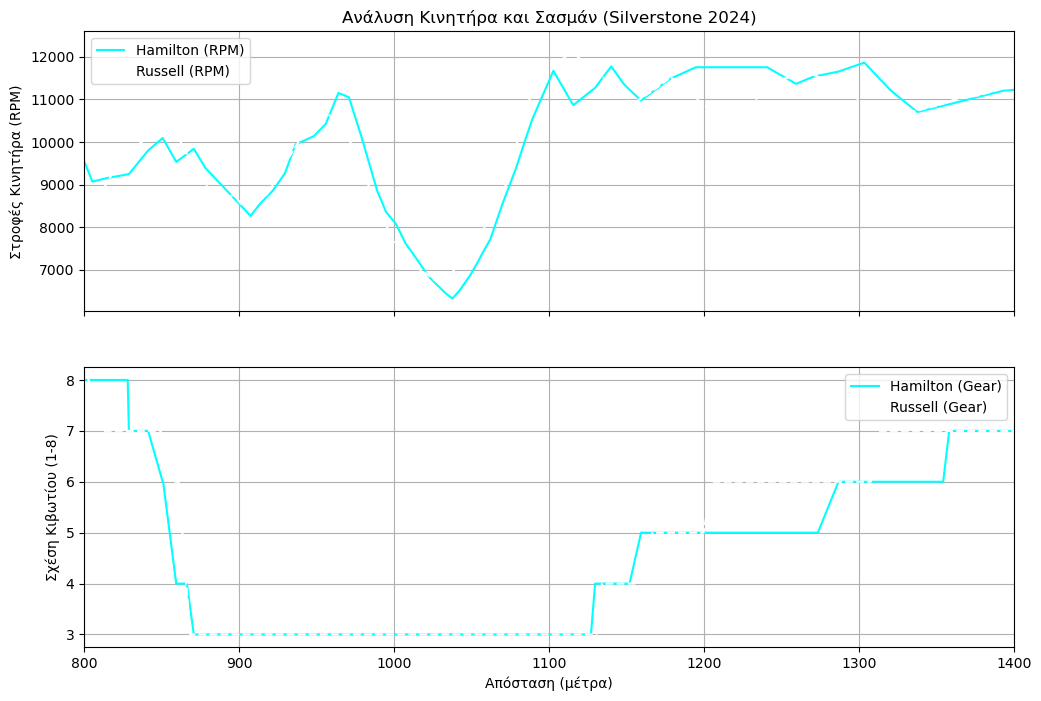

In [9]:
import matplotlib.pyplot as plt

# 1. Παίρνουμε την ΠΛΗΡΗ τηλεμετρία (get_telemetry) που περιέχει και τα Gears
ham_telemetry_correct = ham_lap.get_telemetry().add_distance()
rus_telemetry_correct = rus_lap.get_telemetry().add_distance()

# 2. Φτιάχνουμε τα γραφήματα
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Πάνω γράφημα: Στροφές Κινητήρα (RPM)
ax[0].plot(ham_telemetry_correct['Distance'], ham_telemetry_correct['RPM'], label='Hamilton (RPM)', color='cyan')
ax[0].plot(rus_telemetry_correct['Distance'], rus_telemetry_correct['RPM'], label='Russell (RPM)', color='white', linestyle='--')
ax[0].set_ylabel('Στροφές Κινητήρα (RPM)')
ax[0].title.set_text('Ανάλυση Κινητήρα και Σασμάν (Silverstone 2024)')
ax[0].legend()
ax[0].grid(True)

# Κάτω γράφημα: Σχέση στο Κιβώτιο (nGear) - Στο πλήρες telemetry ονομάζεται nGear!
ax[1].plot(ham_telemetry_correct['Distance'], ham_telemetry_correct['nGear'], label='Hamilton (Gear)', color='cyan')
ax[1].plot(rus_telemetry_correct['Distance'], rus_telemetry_correct['nGear'], label='Russell (Gear)', color='white', linestyle='--')
ax[1].set_ylabel('Σχέση Κιβωτίου (1-8)')
ax[1].set_xlabel('Απόσταση (μέτρα)')
ax[1].legend()
ax[1].grid(True)

# Κάνουμε Zoom στο ίδιο ακριβώς σημείο (800m - 1400m)
plt.xlim(800, 1400)

plt.show()